In [5]:
import pandas as pd
import os
import numpy as np
from pathlib import Path
import json
import scenario_discovery_functions.scenario_discovery_functions as sdf


SAVE_CSV = False
SAVE_FIG = False

CURR_DIR = Path(os.getcwd()).parent
YEAR_1 = 2035
CONDITION_1 = "<"
THRESHOLD_1 = 0.25
YEAR_2 = 2050
CONDITION_2 = ">"
THRESHOLD_2 = 0.75
PRIM_THRESHOLD = 0.5

def get_cluster_name(condition, threshold):
    if condition == ">" and threshold == 0.75:
        name = "high"
    elif condition == "<" and threshold == 0.25:
        name = "low"
    else:
        raise ValueError("Condition and threshold combination not recognized.")
    return name


analysis_name = (
    str(YEAR_1)
    + "_"
    + get_cluster_name(CONDITION_1, THRESHOLD_1)
    + "_"
    + str(YEAR_2)
    + "_"
    + get_cluster_name(CONDITION_2, THRESHOLD_2)
)

def read_csv_file(file_path, **kwargs):
    df = pd.read_csv(file_path, **kwargs)
    return df

# Read the csv files
bridge885_2050 = read_csv_file("Bridge_885_year2050_ema_road_model_08_05_2024_results.csv", index_col=0)
bridge885_2035 = read_csv_file("Bridge_885_year2035_ema_road_model_08_05_2024_results.csv", index_col=0)

bridge885_ic_ratios = read_csv_file(CURR_DIR / "output_simulations/ema_road_model_08_05_2024/bridges/individual/ema_road_model_08_05_2024_Bridge_885_ICratio.csv")
pass

def convert_relative_to_absolute(df_relative):
    with open(CURR_DIR / "data/init_data/municipalities_area_set.json") as file:
        absolute_jobs_and_population_2019 = json.load(file)
    
    # Get the column names of df_relative
    column_names = df_relative.columns.tolist()
    
    # Find the column index of jobs_xx and population_xx with the lowest and highest number
    jobs_columns = [col for col in column_names if col.lower().startswith('jobs_')] # Get all columns that start with 'jobs_'
    population_columns = [col for col in column_names if col.lower().startswith('population_')] # Get all columns that start with 'population_'

    # Get the absolute values of jobs and population in 2019
    absolute_jobs = absolute_jobs_and_population_2019['data']['area_entities']['jobs.count']
    absolute_population = absolute_jobs_and_population_2019['data']['area_entities']['people.count']

    # Multiply the jobs and population columns by their respective multipliers
    df_absolute = df_relative.copy()
    df_absolute[jobs_columns] = df_absolute[jobs_columns].multiply(absolute_jobs, axis=1) / 100
    df_absolute[population_columns] = df_absolute[population_columns].multiply(absolute_population, axis=1) / 100

    # Sum the local (i.e. jobs and population) columns
    df_absolute['total_jobs'] = df_absolute[jobs_columns].sum(axis=1)
    df_absolute['total_population'] = df_absolute[population_columns].sum(axis=1)

    # Drop the local columns
    df_absolute = df_absolute.drop(columns=jobs_columns + population_columns)

    df_absolute["IC ratio"] = df_absolute.iloc[:,-3]
    df_absolute = df_absolute.drop(columns=["885"])

    return df_absolute


# Ensure the dataframes have the same columns and index
assert bridge885_2050.columns.equals(bridge885_2035.columns)
assert bridge885_2050.index.equals(bridge885_2035.index)

bridge885_2035.iloc[:,-1] = bridge885_ic_ratios.loc[:,"2035"]

bridge885_2050 = convert_relative_to_absolute(bridge885_2050)
bridge885_2035 = convert_relative_to_absolute(bridge885_2035)

# Perform element-wise division
df_divided = bridge885_2050.div(bridge885_2035)
df_divided.iloc[:,-1] = bridge885_2050.iloc[:,-1]

# Save the divided dataframe to a csv file
if SAVE_CSV:
    df_divided.to_csv("Bridge_885_year2050_divided_by_2035.csv")

# Split the dataframe into X (input_) and Y (output) for scenario discovery
x_scenario_discovery = df_divided.iloc[:,:-1]
y_scenario_discovery = df_divided.iloc[:,-1]

# Declare cases of interest
binary_array_coi = sdf.binarize_array_complex(
    ic_dataframe=bridge885_ic_ratios,
    year_1=YEAR_1,
    threshold_1=THRESHOLD_1,
    condition_1=CONDITION_1,
    year_2=YEAR_2,
    threshold_2=THRESHOLD_2,
    condition_2=CONDITION_2,
)
print(f"Cases of interest: {binary_array_coi.sum()}")

y_scenario_discovery_coi = np.array(binary_array_coi.astype(int))
print()

/tmp/ipykernel_5731/2491676490.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_absolute['total_jobs'] = df_absolute[jobs_columns].sum(axis=1)
/tmp/ipykernel_5731/2491676490.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_absolute['total_population'] = df_absolute[population_columns].sum(axis=1)


Cases of interest: 32



/tmp/ipykernel_5731/2491676490.py:73: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_absolute['total_jobs'] = df_absolute[jobs_columns].sum(axis=1)
/tmp/ipykernel_5731/2491676490.py:74: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_absolute['total_population'] = df_absolute[population_columns].sum(axis=1)


## Logistic regression

In [6]:
lr_object = sdf.logistic_regression(x_scenario_discovery, y_scenario_discovery_coi)


Optimization terminated successfully.
         Current function value: 0.141273
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.140323
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.140718
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.141351
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.141626
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.141627
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.141292
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.141624
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.140867
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.141412
  

/home/workspace-user/code/models_infrastructure_interdependency/venv/lib/python3.10/site-packages/ema_workbench/analysis/logistic_regression.py:67: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)
/home/workspace-user/code/models_infrastructure_interdependency/venv/lib/python3.10/site-packages/ema_workbench/analysis/logistic_regression.py:257: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  self.peeling_trajectory = pd.concat(


/home/workspace-user/code/models_infrastructure_interdependency/venv/lib/python3.10/site-packages/ema_workbench/analysis/logistic_regression.py:67: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


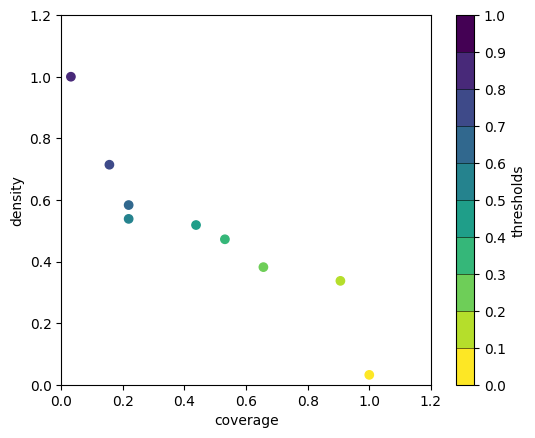

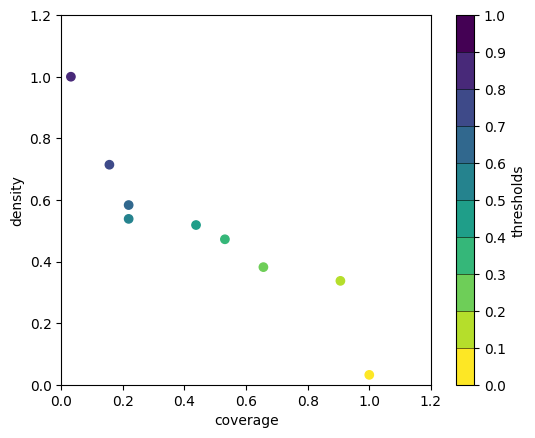

In [ ]:
Number_of_models = len(lr_object.models) - 1 
lr_object.show_threshold_tradeoff(Number_of_models)

In [ ]:
lr_object.inspect(Number_of_models)

    coverage   density  thresholds
0   1.000000  0.089000         0.0
1   0.696629  0.175637         0.1
2   0.022472  0.022989         0.2
3   0.000000  0.000000         0.3
4   0.000000       NaN         0.4
5   0.000000       NaN         0.5
6   0.000000       NaN         0.6
7   0.000000       NaN         0.7
8   0.000000       NaN         0.8
9   0.000000       NaN         0.9
10  0.000000       NaN         1.0

                            Results: Logit
Model:                 Logit             Method:            MLE       
Dependent Variable:    y                 Pseudo R-squared:  0.087     
Date:                  2025-02-07 14:48  AIC:               552.4635  
No. Observations:      1000              BIC:               562.2790  
Df Model:              1                 Log-Likelihood:    -274.23   
Df Residuals:          998               LL-Null:           -300.22   
Converged:             1.0000            LLR p-value:       5.6279e-13
No. Iterations:        7.0000          

/home/workspace-user/code/models_infrastructure_interdependency/venv/lib/python3.10/site-packages/ema_workbench/analysis/logistic_regression.py:67: RuntimeWarning: invalid value encountered in scalar divide
  precision = tp / (tp + fp)


## PRIM


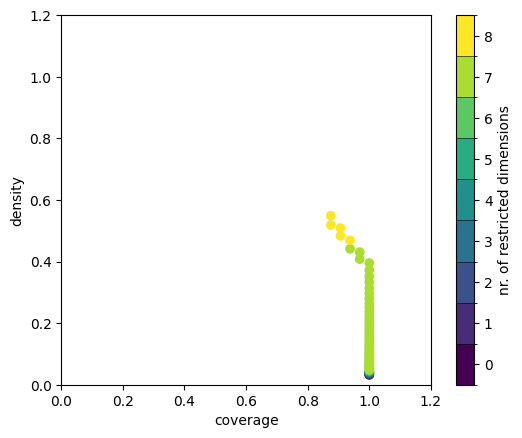

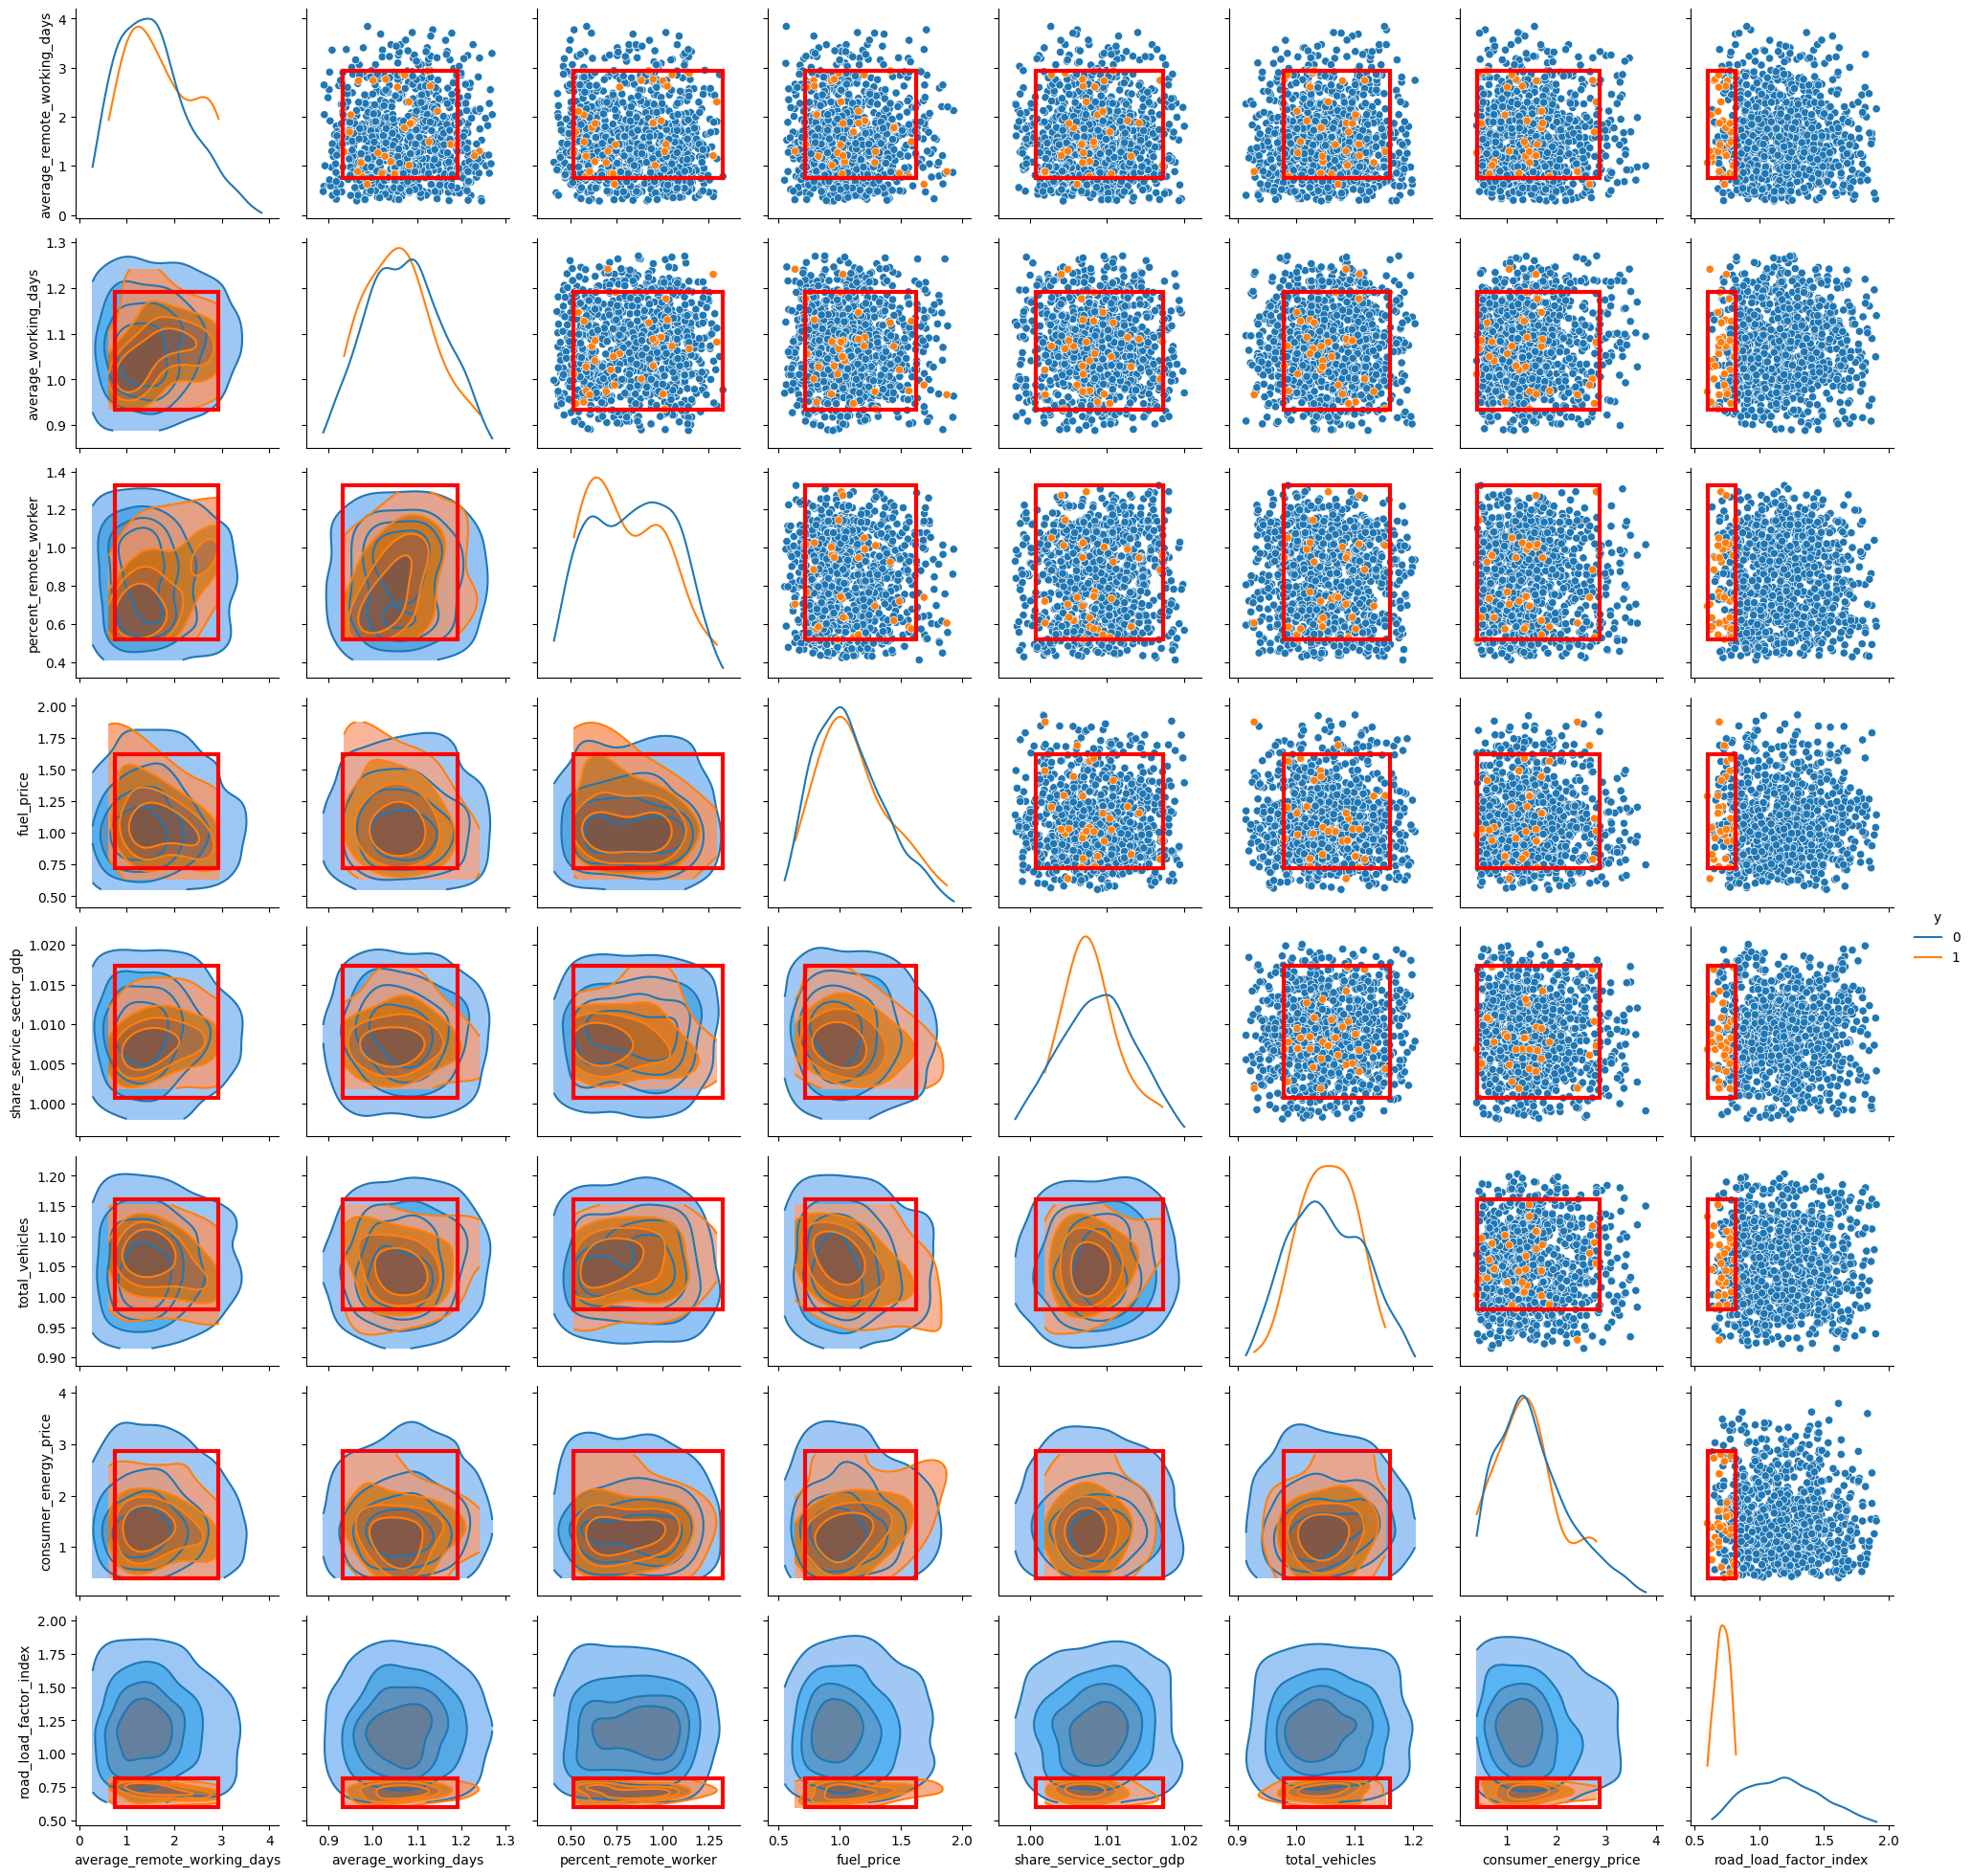

In [7]:
import importlib
importlib.reload(sdf)

prim_object, box = sdf.prim(x_scenario_discovery, y_scenario_discovery_coi, prim_threshold=PRIM_THRESHOLD)
box_lims = box.box_lims
# print(box_lims)
pass

## Classification trees

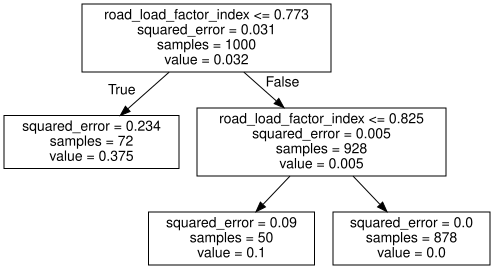

In [15]:
from IPython.display import SVG, display

cart_object = sdf.cart(x_scenario_discovery, y_scenario_discovery_coi)
cart_object.build_tree()
svg_tree = cart_object.show_tree(format="svg")
display(SVG(svg_tree))

# Save the figure in the subfolder 'plots'
if SAVE_FIG:
    plots_dir = Path("plots")
    plots_dir.mkdir(exist_ok=True)
    with open(plots_dir / f"multicondition_cart_tree_bridge885_{analysis_name}.svg", "w") as f:
        f.write(svg_tree.decode("utf-8"))